In [2]:
# !pip install matplotlib wordcloud

In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation, BatchNormalization, Input, Embedding, Dot, Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard, EarlyStopping

from wordcloud import WordCloud
%matplotlib inline

### READING ANIMELIST.CSV

In [4]:
import os 


In [5]:
INPUT_DIR = os.path.join("..","artifacts","raw")

In [6]:
rating_df = pd.read_csv(INPUT_DIR+"/animelist.csv", low_memory=True, usecols=["user_id","anime_id","rating"]) 
rating_df.head(2)

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7


In [7]:
rating_df.shape

(5000000, 3)

### Data Processing

In [8]:
# removing infrequent users, keeping experienced users

n_rating = rating_df['user_id'].value_counts()
rating_df = rating_df[rating_df["user_id"].isin(n_rating[n_rating>=400].index)].copy()

In [9]:
rating_df.shape

(3246641, 3)

In [10]:
min_rating = min(rating_df["rating"])
max_rating = max(rating_df["rating"])
avg_rating = np.mean(rating_df["rating"])

In [11]:
print(min_rating, max_rating, avg_rating)

0 10 4.122732695114736


In [12]:
## Min Max Scaling 

rating_df["rating"] = rating_df["rating"].apply(lambda x : (x-min_rating)/(max_rating-min_rating)).astype('float')

In [13]:
min_rating = min(rating_df["rating"])
max_rating = max(rating_df["rating"])
avg_rating = np.mean(rating_df["rating"])

print(min_rating, max_rating, avg_rating)

0.0 1.0 0.4122732695114736


In [14]:
## checking duplicated 

rating_df.duplicated().sum()

np.int64(0)

In [15]:
# checking null values 

rating_df.isna().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [16]:
## User ---> 10054 ---Encoding----> 98 
# user encoding and decoding 
user_ids = rating_df["user_id"].unique().tolist()
user2user_encoded = {x : i for i, x in enumerate(user_ids)}
user2user_decoded = {i : x for i, x in enumerate(user_ids)}

rating_df['user'] = rating_df["user_id"].map(user2user_encoded)

rating_df.head()

,user_id,anime_id,rating,user
213,2,24833,0.0,0
214,2,235,1.0,0
215,2,36721,0.0,0
216,2,40956,0.0,0
217,2,31933,0.0,0


In [17]:
n_users = len(user2user_encoded)
n_users

4203

In [18]:
anime_ids = rating_df["anime_id"].unique().tolist()
anime2anime_encoded = {x : i for i, x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i, x in enumerate(anime_ids)}

rating_df['anime'] = rating_df["anime_id"].map(anime2anime_encoded)

rating_df.head()

,user_id,anime_id,rating,user,anime
213,2,24833,0.0,0,0
214,2,235,1.0,0,1
215,2,36721,0.0,0,2
216,2,40956,0.0,0,3
217,2,31933,0.0,0,4


In [19]:
n_anime = len(anime2anime_encoded)
n_anime

17149

In [20]:
rating_df = rating_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
X = rating_df[["user", "anime"]].values
y = rating_df["rating"]

In [22]:
test_size = 1000
train_indices = rating_df.shape[0] - test_size

In [23]:
X_train, X_test, y_train, y_test = (
    X[:train_indices],
    X[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

In [24]:
len(X_train), len(X_test)

(3245641, 1000)

In [25]:
type(X_train)

numpy.ndarray

In [26]:
X_train_array = [X_train[:, 0], X_train[:, 1]]
X_test_array = [X_test[:, 0], X_test[:, 1]]

In [27]:
type(X_train_array)

list

In [28]:
type(X_train_array[0])

numpy.ndarray

### MODEL ARCHITECTURE

In [29]:
def RecommenderNet():
    embedding_size = 128

    user = Input(name="user", shape=[1])
    user_embedding = Embedding(name="user_embedding", input_dim=n_users, output_dim=embedding_size)(user)

    anime = Input(name="anime", shape=[1])
    anime_embedding = Embedding(name="anime_embedding", input_dim=n_anime, output_dim=embedding_size)(anime)

    x = Dot(name="dot_product", normalize=True, axes=2)([user_embedding,anime_embedding])

    x = Flatten()(x)

    x = Dense(1, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation("sigmoid")(x)

    model = Model(inputs = [user, anime], outputs=x)
    model.compile(loss="binary_crossentropy", metrics=["mae", "mse"], optimizer='Adam')

    return model


In [30]:
model = RecommenderNet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    537,984 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,195,072 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_product[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1)         │          4 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,733,062 (10.43 MB)

 Trainable params: 2,733,060 (10.43 MB)

 Non-trainable params: 2 (8.00 B)

In [31]:
start_lr = 0.00001
min_lr = 0.00001
max_lr = 0.00005

batch_size = 10000

ramup_epochs = 5
sustain_epochs = 0
exp_decay = 0.8

In [32]:
def lrfn(epoch):
    if epoch < ramup_epochs:
        return (max_lr-start_lr)/ ramup_epochs*epoch + start_lr
    elif epoch < ramup_epochs+sustain_epochs:
        return max_lr
    else:
        return (max_lr-min_lr) * exp_decay ** (epoch-ramup_epochs-sustain_epochs)+ min_lr

In [33]:
lr_callback = LearningRateScheduler(lambda epoch: lrfn(epoch), verbose = 0)
checkpoint_filepath = './weights.weights.h5'

model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath, save_weights_only=True, 
                                   monitor="val_loss", mode="min", save_best_only=True)

early_stopping = EarlyStopping(patience=3, monitor="val_loss", 
                               mode="min", restore_best_weights=True)

In [34]:
my_callbacks = [model_checkpoint, lr_callback, early_stopping]

In [35]:
history = model.fit(
            x= X_train_array,
            y = y_train,
            batch_size = batch_size,
            epochs = 20,
            verbose = 1,
            validation_data = (X_test_array, y_test),
            callbacks = my_callbacks
        )

Epoch 1/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.7998 - mae: 0.3820 - mse: 0.1971 - val_loss: 0.7255 - val_mae: 0.3675 - val_mse: 0.1715 - learning_rate: 1.0000e-05
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7963 - mae: 0.3807 - mse: 0.1957 - val_loss: 0.7846 - val_mae: 0.3780 - val_mse: 0.1925 - learning_rate: 1.8000e-05
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7903 - mae: 0.3785 - mse: 0.1933 - val_loss: 0.7887 - val_mae: 0.3785 - val_mse: 0.1937 - learning_rate: 2.6000e-05
Epoch 4/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.7817 - mae: 0.3751 - mse: 0.1899 - val_loss: 0.7850 - val_mae: 0.3777 - val_mse: 0.1923 - learning_rate: 3.4000e-05


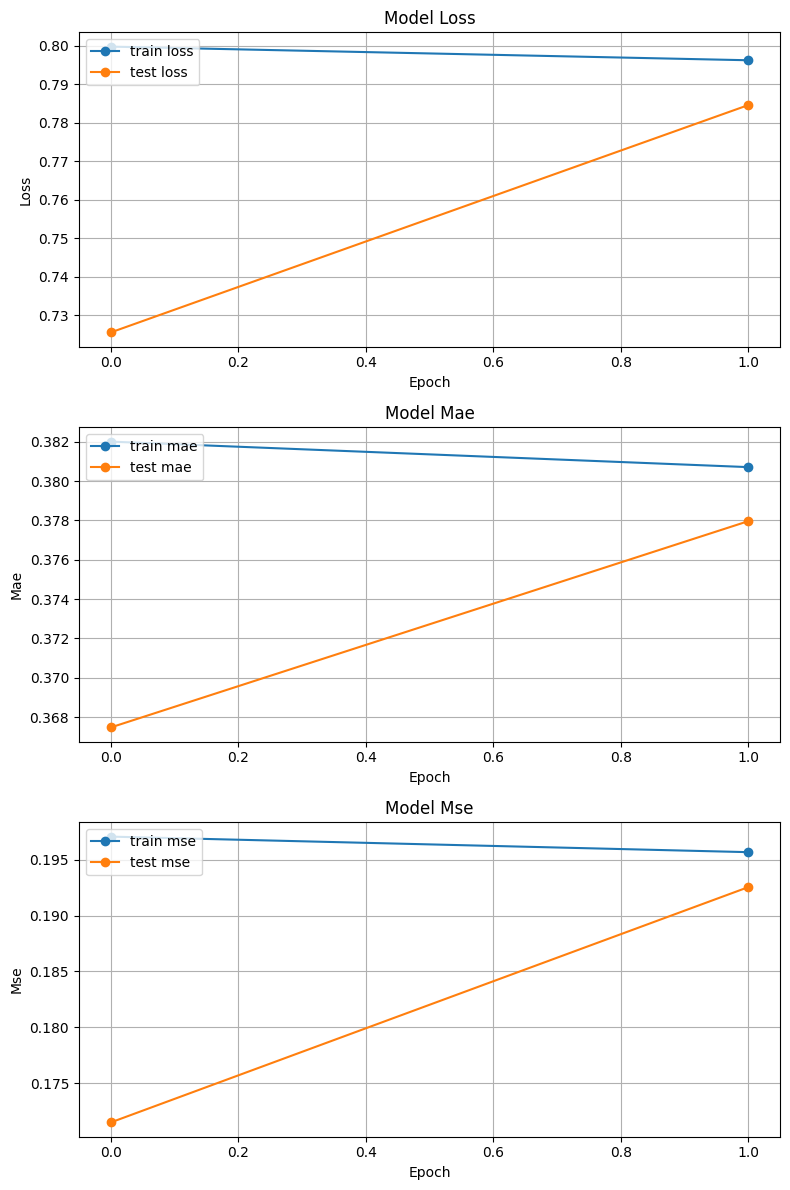

In [36]:
metrics = ["loss", "mae", "mse"]

# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric][0:-2], marker="o", label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"][0:-2], marker="o", label=f"test {metric}")
    ax.set_title(f"Model {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper left")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [37]:
def extract_weights(name, model):
    weight_layer = model.get_layer(name)
    weights = weight_layer.get_weights()[0]
    weights = weights/ np.linalg.norm(weights, axis=1).reshape((-1,1))
    return weights

In [38]:
anime_weights = extract_weights("anime_embedding", model)

In [39]:
user_weights = extract_weights("user_embedding", model)


### READING ANIME.CSV

In [40]:
df = pd.read_csv(INPUT_DIR+"/anime.csv", low_memory=True)
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0


In [41]:
df = df.replace("Unknown", np.nan)

In [42]:
def get_anime_name(anime_id):
    try:
        name = df[df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = df[df.anime_id == anime_id].Name.values[0]
    except:
        print("Error")
    return name

In [43]:
df["anime_id"] = df["MAL_ID"]
df['eng_version'] = df['English name']
df['eng_version'] = df.anime_id.apply(lambda x: get_anime_name(x))

In [44]:
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,...,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0,5,Cowboy Bebop:The Movie


In [45]:
get_anime_name(6702)

'Fairy Tail'

In [46]:
df.sort_values(by=['Score'],
               inplace=True,
               ascending=False,
               kind="quicksort",
               na_position="last")

In [47]:
df.columns

Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
       'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
       'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
       'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
       'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
       'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'anime_id',
       'eng_version'],
      dtype='object')

In [48]:
df = df[["anime_id", "eng_version", "Score", "Genres", "Episodes", "Type", "Premiered", "Members"]]
df.head(2)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [49]:
def getAnimeFrame(anime, df):
    if isinstance(anime, int):
        return df[df.anime_id == anime]
    if isinstance(anime, str):
        return df[df.eng_version == anime]



In [50]:
getAnimeFrame(40028, df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [51]:
getAnimeFrame('Steins;Gate', df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162


### ANIME_WITH_SYNOPSIS.CSV

In [52]:
cols = ["MAL_ID", "Name", "Genres", "sypnopsis"]

synopsis_df = pd.read_csv(INPUT_DIR+"/anime_with_synopsis.csv", usecols=cols)
synopsis_df.head(2)

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."


In [53]:
def getSynopsis(anime, df):
    if isinstance(anime, int):
        return df[df.MAL_ID == anime].sypnopsis.values[0]
    if isinstance(anime, str):
        return df[df.Name == anime].sypnopsis.values[0]


In [54]:
getSynopsis(40028, synopsis_df)

"Gabi Braun and Falco Grice have been training their entire lives to inherit one of the seven titans under Marley's control and aid their nation in eradicating the Eldians on Paradis. However, just as all seems well for the two cadets, their peace is suddenly shaken by the arrival of Eren Yeager and the remaining members of the Survey Corps. Having finally reached the Yeager family basement and learned about the dark history surrounding the titans, the Survey Corps has at long last found the answer they so desperately fought to uncover. With the truth now in their hands, the group set out for the world beyond the walls. In Shingeki no Kyojin: The Final Season , two utterly different worlds collide as each party pursues its own agenda in the long-awaited conclusion to Paradis' fight for freedom."

In [55]:
getSynopsis('Steins;Gate', synopsis_df)

'The self-proclaimed mad scientist Rintarou Okabe rents out a room in a rickety old building in Akihabara, where he indulges himself in his hobby of inventing prospective "future gadgets" with fellow lab members: Mayuri Shiina, his air-headed childhood friend, and Hashida Itaru, a perverted hacker nicknamed "Daru." The three pass the time by tinkering with their most promising contraption yet, a machine dubbed the "Phone Microwave," which performs the strange function of morphing bananas into piles of green gel. Though miraculous in itself, the phenomenon doesn\'t provide anything concrete in Okabe\'s search for a scientific breakthrough; that is, until the lab members are spurred into action by a string of mysterious happenings before stumbling upon an unexpected success—the Phone Microwave can send emails to the past, altering the flow of history. Adapted from the critically acclaimed visual novel by 5pb. and Nitroplus, Steins;Gate takes Okabe through the depths of scientific theory 

### CONTENT/ITEM BASED RECOMMENDATION 

In [56]:
pd.set_option("max_colwidth", None)

In [ ]:
def find_similar_animes(name, anime_weights, anime2anime_encoded, 
                        anime2anime_decoded, df, synopsis_df, n=10, return_dist=False, neg=False):
    
    try:
        index = getAnimeFrame(name, df).anime_id.values[0]
        encoded_index = anime2anime_encoded.get(index)

        weights = anime_weights

        dists = np.dot(weights, weights[encoded_index])
        sorted_dist = np.argsort(dists)

        n = n+1
        
        if neg:
            closest = sorted_dist[:n]
        else:
            closest = sorted_dist[-n::1]
        
        print(f"Anime closed to {name} is {closest}")
        if return_dist:
            return dists, closest
        
        SimilarityArr = []
        for close in closest:

            decoded_id = anime2anime_decoded.get(close)
            
            # synopsis = getSynopsis(decoded_id, synopsis_df)
            
            anime_frame = getAnimeFrame(decoded_id, df)
            
            anime_name = anime_frame.eng_version.values[0]
            genre = anime_frame.Genres.values[0]
            similarity = dists[close]
            
            SimilarityArr.append({
                "anime_id": decoded_id,
                "name": anime_name,
                "similarity": similarity,
                "genre": genre,
                # "synopsis": synopsis
            })

        Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
        return Frame[Frame.anime_id != index].drop(["anime_id"], axis = 1)
    except Exception as e:
        print(f"Getting error {e}")

In [58]:
find_similar_animes(
    "Steins;Gate",
    anime_weights,
    anime2anime_encoded,
    anime2anime_decoded,
    df,
    synopsis_df,
    n=2)

Anime closed to Steins;Gate is [10935  3653    69]


,name,similarity,genre,synopsis
1,Nodame Cantabile: Nodame to Chiaki no Umi Monogatari,0.361254,"Comedy, Josei, Romance, Slice of Life","orld-class conductor Franz von Stresemann sends his favorite music students Shinichi Chiaki, Megumi ""Nodame"" Noda, Ryuutarou Mine, and Masumi Okuyama to the Nina Lutz Music Festival in Nagano to study under other famous masters. During their car ride, Chiaki is irritated by his friends' antics, but later wakes up from a nap to discover that they took a detour to a beach in Niigata. Mine tans under the bright sun while Nodame and Masumi enjoy a refreshing swim; Chiaki sits inside the beach club, trying his best to hide his fear of the sea. When Nodame suggests renting an inflatable boat to row over to a small island, will Chiaki be able to keep his secret?"
0,009 Re:Cyborg x Zip,0.322366,"Comedy, Super Power",series of animated shorts done in collaboration with Zip.


### USER BASED RECOMMENDATION

In [59]:
def find_similar_users(item_input, user_weights, user2user_encoded, user2user_decoded, n = 10,
                        return_dist=False, neg=False):
    try:
        index = item_input
        encoded_index = user2user_encoded.get(index)

        weights = user_weights
        dists = np.dot(weights, weights[encoded_index])
        # it gives index on the basis sorting of similarity we get in dists
        sorted_dist = np.argsort(dists)

        n = n+1
        
        if neg:
            closest = sorted_dist[:n]
        else:
            closest = sorted_dist[-n:]

        if return_dist:
            return dists, closest
        SimilarityArr = []
        for close in closest:
            similarity = dists[close]

            if isinstance(item_input, int):
                decoded_id = user2user_decoded.get(close)

                SimilarityArr.append({
                    "similar_users": decoded_id,
                    "similarity": similarity,
                })
        similar_users = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
        similar_users = similar_users[similar_users.similar_users != item_input]
        return similar_users
    
    except Exception as e:
        print(f"Getting error {e}")
                

In [60]:
find_similar_users(11880, user_weights, user2user_encoded, user2user_decoded)

,similar_users,similarity
9,1733,0.350538
8,9621,0.282451
7,11613,0.282345
6,9835,0.276807
5,15545,0.258036
4,5828,0.247205
3,11885,0.247199
2,8235,0.245002
1,325,0.244608
0,16341,0.243642


In [61]:
def showWordCloud(all_genres):
    genres_cloud = WordCloud(width=700, height=400, background_color='white', colormap='gnuplot').generate_from_frequencies(all_genres)
    plt.figure(figsize=(10,8))
    plt.imshow(genres_cloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

In [62]:
from collections import defaultdict

In [63]:
def getFavGenre(frame , plot=False):
    frame.dropna(inplace=False)
    all_genres = defaultdict(int)

    genres_list = []
    for genres in frame["Genres"]:
        if isinstance(genres,str):
            for genre in genres.split(','):
                genres_list.append(genre)
                all_genres[genre.strip()] += 1

    if plot:
        showWordCloud(all_genres)
    else:
        return genres_list

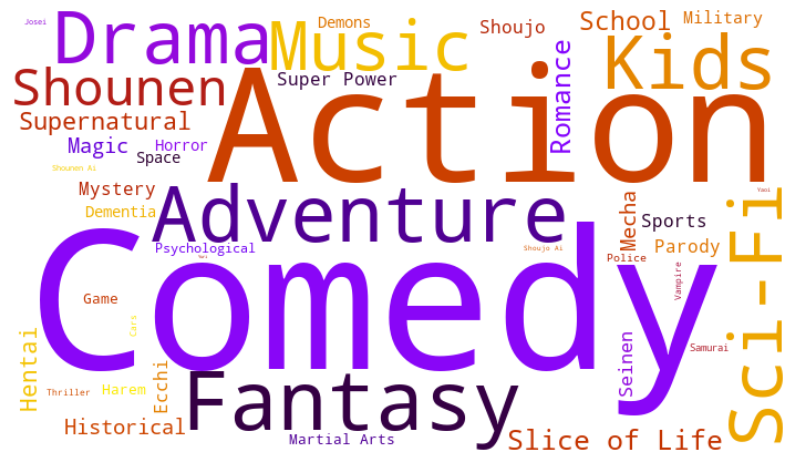

In [64]:
getFavGenre(df, True)

In [65]:
def get_user_preferences(user_id , rating_df , df ,plot=False):

    animes_watched_by_user = rating_df[rating_df.user_id == user_id]
    # get rating that is 75 percentile
    user_rating_percentile = np.percentile(animes_watched_by_user.rating , 75)
    # get rating that are in top 25 percentile by occurance in user's rating
    animes_watched_by_user = animes_watched_by_user[animes_watched_by_user.rating >= user_rating_percentile]

    top_animes_user = (
        animes_watched_by_user.sort_values(by="rating" , ascending=False).anime_id.values
    )
    # getting top animes details from anime dataframe
    anime_df_rows = df[df["anime_id"].isin(top_animes_user)]
    anime_df_rows = anime_df_rows[["eng_version","Genres"]]

    if plot:
        getFavGenre(anime_df_rows,plot)


    return anime_df_rows

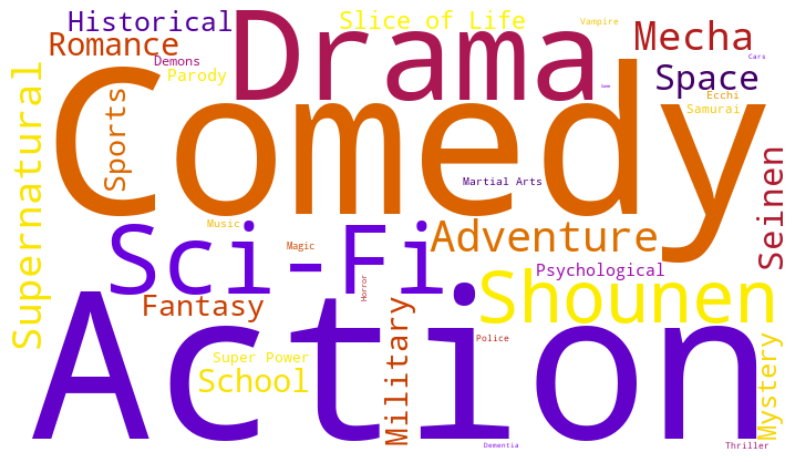

,eng_version,Genres
3971,Fullmetal Alchemist:Brotherhood,"Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen"
9913,Gintama Season 4,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen"
6474,Hunter x Hunter,"Action, Adventure, Fantasy, Shounen, Super Power"
6006,Gintama Season 2,"Action, Sci-Fi, Comedy, Historical, Parody, Samurai, Shounen"
741,Legend of the Galactic Heroes,"Military, Sci-Fi, Space, Drama"
...,...,...
2575,Shootfighter Tekken,"Action, Martial Arts, Shounen"
8064,Samurai Flamenco,"Action, Comedy, Parody, Super Power"
510,Venus Wars,"Action, Sci-Fi, Adventure, Space"
6864,Saint Seiya Omega,"Action, Adventure, Fantasy, Shounen"


In [66]:
get_user_preferences(11880 , rating_df, df , plot=True)

In [71]:
def get_user_recommendations(similar_users , user_pref ,df , synopsis_df, rating_df, n=10):

    recommended_animes = []
    anime_list = []

    for user_id in similar_users.similar_users.values:
        # get anime of similar usr's from current user
        pref_list = get_user_preferences(int(user_id) , rating_df, df)
        # removing anime watched by current user
        pref_list = pref_list[~pref_list.eng_version.isin(user_pref.eng_version.values)]

        if not pref_list.empty:
            anime_list.append(pref_list.eng_version.values)

    if anime_list:
            anime_list = pd.DataFrame(anime_list)

            sorted_list = pd.DataFrame(pd.Series(anime_list.values.ravel()).value_counts()).head(n)

            for i,anime_name in enumerate(sorted_list.index):
                n_user_pref = sorted_list[sorted_list.index == anime_name].values[0][0]

                if isinstance(anime_name,str):
                    frame = getAnimeFrame(anime_name,df)
                    anime_id = frame.anime_id.values[0]
                    genre = frame.Genres.values[0]
                    synopsis = getSynopsis(int(anime_id),synopsis_df)

                    recommended_animes.append({
                        "n" : n_user_pref,
                        "anime_name" : anime_name,
                        "Genres" : genre,
                        "Synopsis": synopsis
                    })
    return pd.DataFrame(recommended_animes).head(n)
    

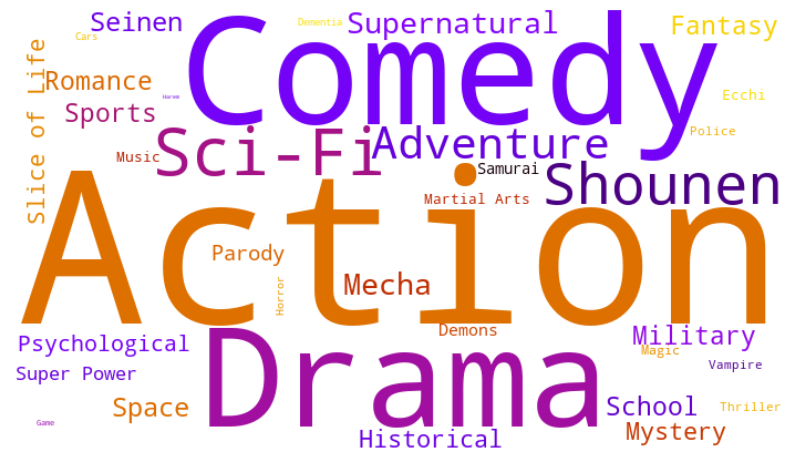

,n,anime_name,Genres,Synopsis
0,10,Nisekoi:False Love,"Harem, Comedy, Romance, School, Shounen","aku Ichijou, a first-year student at Bonyari High School, is the sole heir to an intimidating yakuza family. Ten years ago, Raku made a promise to his childhood friend. Now, all he has to go on is a pendant with a lock, which can only be unlocked with the key which the girl took with her when they parted. Now, years later, Raku has grown into a typical teenager, and all he wants is to remain as uninvolved in his yakuza background as possible while spending his school days alongside his middle school crush Kosaki Onodera. However, when the American Bee Hive Gang invades his family's turf, Raku's idyllic romantic dreams are sent for a toss as he is dragged into a frustrating conflict: Raku is to pretend that he is in a romantic relationship with Chitoge Kirisaki, the beautiful daughter of the Bee Hive's chief, so as to reduce the friction between the two groups. Unfortunately, reality could not be farther from this whopping lie—Raku and Chitoge fall in hate at first sight, as the girl is convinced he is a pathetic pushover, and in Raku's eyes, Chitoge is about as attractive as a savage gorilla. Nisekoi follows the daily antics of this mismatched couple who have been forced to get along for the sake of maintaining the city's peace. With many more girls popping up his life, all involved with Raku's past somehow, his search for the girl who holds his heart and his promise leads him in more unexpected directions than he expects."
1,9,Death Note,"Mystery, Police, Psychological, Supernatural, Thriller, Shounen","shinigami, as a god of death, can kill any person—provided they see their victim's face and write their victim's name in a notebook called a Death Note. One day, Ryuk, bored by the shinigami lifestyle and interested in seeing how a human would use a Death Note, drops one into the human realm. High school student and prodigy Light Yagami stumbles upon the Death Note and—since he deplores the state of the world—tests the deadly notebook by writing a criminal's name in it. When the criminal dies immediately following his experiment with the Death Note, Light is greatly surprised and quickly recognizes how devastating the power that has fallen into his hands could be. With this divine capability, Light decides to extinguish all criminals in order to build a new world where crime does not exist and people worship him as a god. Police, however, quickly discover that a serial killer is targeting criminals and, consequently, try to apprehend the culprit. To do this, the Japanese investigators count on the assistance of the best detective in the world: a young and eccentric man known only by the name of L."
2,9,KonoSuba:God's Blessing on This Wonderful World!,"Adventure, Comedy, Fantasy, Magic, Parody, Supernatural","fter dying a laughable and pathetic death on his way back from buying a game, high school student and recluse Kazuma Satou finds himself sitting before a beautiful but obnoxious goddess named Aqua. She provides the NEET with two options: continue on to heaven or reincarnate in every gamer's dream—a real fantasy world! Choosing to start a new life, Kazuma is quickly tasked with defeating a Demon King who is terrorizing villages. But before he goes, he can choose one item of any kind to aid him in his quest, and the future hero selects Aqua. But Kazuma has made a grave mistake—Aqua is completely useless! Unfortunately, their troubles don't end here; it turns out that living in such a world is far different from how it plays out in a game. Instead of going on a thrilling adventure, the duo must first work to pay for their living expenses. Indeed, their misfortunes have only just begun!"
3,8,Angel Beats!,"Action, Comedy, Drama, School, Supernatural","Otonashi awakens only to learn he is dead. A rifle-toting girl named Yuri explains that they are in the afterlife, and Otonashi realizes the only thing he can remember about himself is

In [72]:
similar_users = find_similar_users(11880, user_weights, user2user_encoded, user2user_decoded)
user_pref = get_user_preferences(11880 , rating_df, df , plot=True)

get_user_recommendations(similar_users, user_pref, df, synopsis_df, rating_df)

### HYBRID RECOMMENDER SYSTEM

In [82]:
def hybrid_recommendation(user_id , user_weight=0.5, content_weight =0.5):

    ## User Recommndation

    similar_users =find_similar_users(user_id,user_weights,user2user_encoded,user2user_decoded)
    user_pref = get_user_preferences(user_id , rating_df, df)
    user_recommended_animes =get_user_recommendations(similar_users,user_pref,df, synopsis_df,rating_df)
    

    user_recommended_anime_list = user_recommended_animes["anime_name"].tolist()
    print(user_recommended_anime_list)

    #### Content recommendation
    content_recommended_animes = []

    for anime in user_recommended_anime_list:
        similar_animes = find_similar_animes(anime, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df)

        if similar_animes is not None and not similar_animes.empty:
            content_recommended_animes.extend(similar_animes["name"].tolist())
        else:
            print(f"No similar anime found {anime}")
    
    combined_scores = {}

    for anime in user_recommended_anime_list:
        combined_scores[anime] = combined_scores.get(anime,0) + user_weight

    for anime in content_recommended_animes:
        combined_scores[anime] = combined_scores.get(anime,0) + content_weight  

    sorted_animes = sorted(combined_scores.items() , key=lambda x:x[1] , reverse=True)

    return [anime for anime , score in sorted_animes[:10]] 



In [87]:
hybrid_recommendation(15597,0.5,0.5)

['Aldnoah.Zero', 'Fate/Zero', 'Fate/Zero Season 2', 'Bakuman.', 'Fairy Tail', 'Maid Sama!', 'Welcome to the N.H.K.', 'Trigun', 'Time of Eve', 'Hellsing Ultimate']
Anime closed to Aldnoah.Zero is [16662  8617 13210  2945 14996 10577 16584  4191 10644  3724  1136]
Getting error index 0 is out of bounds for axis 0 with size 0
No similar anime found Aldnoah.Zero
Anime closed to Fate/Zero is [ 4379 10915  3100 10354 12947  5911   254  4928  3175 16486   153]
Getting error index 0 is out of bounds for axis 0 with size 0
No similar anime found Fate/Zero
Anime closed to Fate/Zero Season 2 is [10028 13694  2205 12862  1258  7077 15785  2956  8624  2332   154]
Getting error index 0 is out of bounds for axis 0 with size 0
No similar anime found Fate/Zero Season 2
Anime closed to Bakuman. is [14238  3608   601  3616  3835 14809 13861 13368  8910   316  1712]
Anime closed to Fairy Tail is [11480 11555  5700 16613  5829 15418 13573 12068  6330 12822   149]
Getting error index 0 is out of bounds for 

['Aldnoah.Zero',
 'Fate/Zero',
 'Fate/Zero Season 2',
 'Bakuman.',
 'Fairy Tail',
 'Maid Sama!',
 'Welcome to the N.H.K.',
 'Trigun',
 'Time of Eve',
 'Hellsing Ultimate']